In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import matplotlib.image as mpimg
import seaborn as sns

the_months = {1:'January',2:'February',3:'March',4:'April',
              5:'May',6:'June',7:'July',8:'August',9:'September',
              10:'October',11:'November',12:'December'}

###   Load the data   ###
wx_daily = pd.read_csv('https://raw.githubusercontent.com/drolsonmi/weather/refs/heads/main/data/Snow%20Weather_Daily.dat', header=1)
wx_5min = pd.read_csv('https://raw.githubusercontent.com/drolsonmi/weather/refs/heads/main/data/Snow%20Weather_FiveMin.dat', header=1)


###   Clean the data   ###
wx_5min = wx_5min.drop([0,1], axis=0)

###   Make Time and Date columns   ###
wx_5min.insert(0, 'Time', pd.to_datetime(wx_5min['TIMESTAMP']).dt.time)
wx_5min.insert(0, 'Date', pd.to_datetime(wx_5min['TIMESTAMP']).dt.date)

wx_5min.insert(2,'Year', pd.to_datetime(wx_5min['Date']).dt.year)
wx_5min.insert(3,'Month',
               pd.to_datetime(wx_5min['Date']).dt.month.apply(lambda x:the_months[x]))
wx_5min.insert(4,'Day', pd.to_datetime(wx_5min['Date']).dt.day)
wx_5min.insert(5,'Hour', pd.to_datetime(wx_5min['TIMESTAMP']).dt.hour)
wx_5min.insert(6,'Minute', pd.to_datetime(wx_5min['TIMESTAMP']).dt.minute)
wx_5min.insert(7,'Second', pd.to_datetime(wx_5min['TIMESTAMP']).dt.second)

###   Convert date and time to datetime format   ###
wx_5min['TIMESTAMP'] = pd.to_datetime(wx_5min['TIMESTAMP'], format='%Y-%m-%d %H:%M:%S')
wx_5min['Time'] = pd.to_datetime(wx_5min['Time'], format='%H:%M:%S')
wx_5min['Date'] = pd.to_datetime(wx_5min['Date'], format='%Y-%m-%d')

###   Convert data to float   ###
wx_5min['AirTF_Avg'] = wx_5min['AirTF_Avg'].astype(float)

###   Clean the AirTF Data   ###
wx_5min.loc[wx_5min['AirTF_Avg'] > 150, 'AirTF_Avg'] = np.nan
wx_5min.loc[wx_5min['AirTF_Avg'] < -30, 'AirTF_Avg'] = np.nan

###   Convert Precip amounts to Float ###
wx_5min['Rain_Tot'] = wx_5min['Rain_Tot'].apply(float)
wx_5min['HeatedPrecip_Tot'] = wx_5min['HeatedPrecip_Tot'].apply(float)

wx_5min.tail(288)

/tmp/ipykernel_79929/1314740355.py:15: DtypeWarning: Columns (0: RECORD, 1: AirTF_Avg, 2: RH_Avg, 3: WindGust, 4: AveWindSp, 5: WindDir, 6: WindDir_SD, 7: BP_inHg, 8: SlrkW, 9: HeatedPrecip_Tot, 10: HeatedRunTot, 11: Rain_Tot, 12: RainRunTot, 13: TdC_Avg, 14: WC_C_Avg, 15: HI_C_Avg) have mixed types. Specify dtype option on import or set low_memory=False.
  wx_5min = pd.read_csv('https://raw.githubusercontent.com/drolsonmi/weather/refs/heads/main/data/Snow%20Weather_FiveMin.dat', header=1)


,Date,Time,Year,Month,Day,Hour,Minute,Second,TIMESTAMP,RECORD,...,WindDir_SD,BP_inHg,SlrkW,HeatedPrecip_Tot,HeatedRunTot,Rain_Tot,RainRunTot,TdC_Avg,WC_C_Avg,HI_C_Avg
292131,2026-07-21,1900-01-01 20:35:00,2026,July,21,20,35,0,2026-07-21 20:35:00,751008,...,28.4048,30.09,0.006,0.0,0.0,0.0,0.0,58.23,83.2,83.2
292132,2026-07-21,1900-01-01 20:40:00,2026,July,21,20,40,0,2026-07-21 20:40:00,751009,...,29.90801,30.09,0.006,0.0,0.0,0.0,0.0,57.93,82.8,82.8
292133,2026-07-21,1900-01-01 20:45:00,2026,July,21,20,45,0,2026-07-21 20:45:00,751010,...,21.4474,30.09,0.004,0.0,0.0,0.0,0.0,57.84,82.6,82.6
292134,2026-07-21,1900-01-01 20:50:00,2026,July,21,20,50,0,2026-07-21 20:50:00,751011,...,32.78471,30.09,0.001,0.0,0.0,0.0,0.0,57.81,82.2,82.2
292135,2026-07-21,1900-01-01 20:55:00,2026,July,21,20,55,0,2026-07-21 20:55:00,751012,...,29.61203,30.09,0.001,0.0,0.0,0.0,0.0,58.37,81.7,81.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292414,2026-07-22,1900-01-01 20:10:00,2026,July,22,20,10,0,2026-07-22 20:10:00,751291,...,0.0,30.11,0.028,0.0,0.083,0.0,0.06,62.45,75.59,322.5
292415,2026-07-22,1900-01-01 20:15:00,2026,July,22,20,15,0,2026-07-22 20:15:00,751292,...,0.0,30.11,0.025,0.0,0.083,0.0,0.06,62.34,75.34,321.5
292416,2026-07-22,1900-01-01 20:20:00,2026,July,22,20,20,0,2026-07-22 20:20:00,751293,...,0.057562,30.11,0.019,0.0,0.083,0.0,0.06,62.04,75.31,317.1
292417,2026-07-22,1900-01-01 20:25:00,2026,July,22,20,25,0,2026-07-22 20:25:00,751294,...,3.328598,30.11,0.014,0.0,0.083,0.0,0.06,62.13,75.31,318.5


In [102]:
wx_5min.columns

Index(['Date', 'Time', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'Second',
       'TIMESTAMP', 'RECORD', 'AirTF_Avg', 'RH_Avg', 'WindGust', 'AveWindSp',
       'WindDir', 'WindDir_SD', 'BP_inHg', 'SlrkW', 'HeatedPrecip_Tot',
       'HeatedRunTot', 'Rain_Tot', 'RainRunTot', 'TdC_Avg', 'WC_C_Avg',
       'HI_C_Avg'],
      dtype='object')

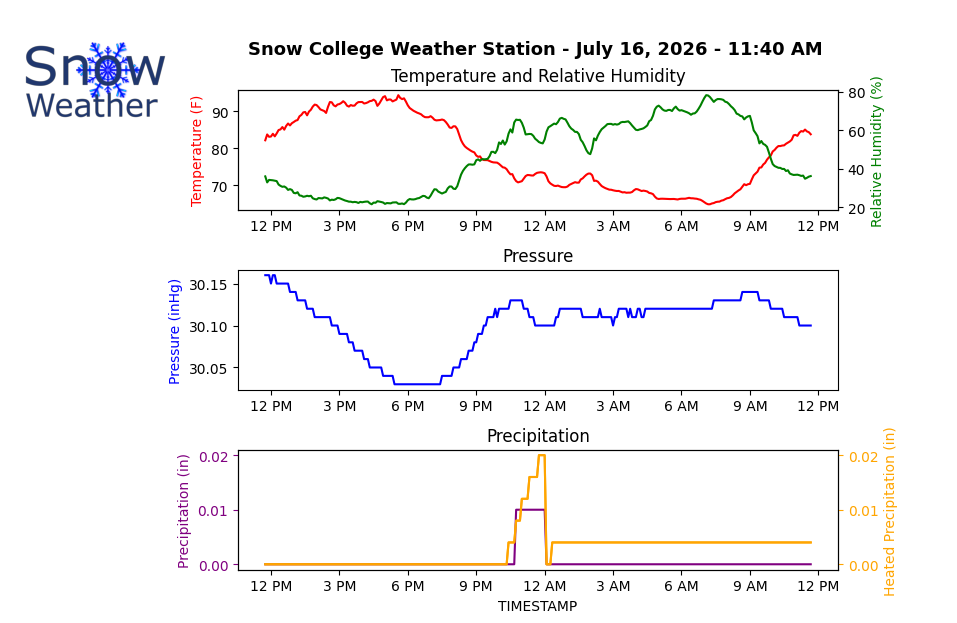

In [125]:
fig = plt.figure(figsize=(12, 12))
fig.text(0.5, 0.98,
         f"Snow College Weather Station - {wx_5min['TIMESTAMP'].iloc[-1].strftime('%B %d, %Y - %I:%M %p')}                    ",
         ha='center',
         fontsize=13,
         fontweight='bold')


###   Snow Weather Logo   ###
img = mpimg.imread('./images/SnowWeatherLogo_Blue.png')
ax_logo = fig.add_axes((0.01, 0.9, 0.14, 0.14))
ax_logo.imshow(img)
ax_logo.axis('off') 

###   Temperature and Relative Humidity   ###

# Temperature
ax_temp = fig.add_axes((0.2, 0.85, 0.5, 0.1))
sns.lineplot(data=wx_5min.tail(288), x='TIMESTAMP', y='AirTF_Avg', ax=ax_temp, color='red')
ax_temp.xaxis.set_major_formatter(mdates.DateFormatter('%-I %p'))
ax_temp.set_xlabel('')
ax_temp.set_ylabel('Temperature (F)', color='red')
ax_temp.set_title('Temperature and Relative Humidity', fontsize=12)

# Relative Humidity
ax_rh = ax_temp.twinx()
sns.lineplot(data=wx_5min.tail(288), x='TIMESTAMP', y='RH_Avg', ax=ax_rh, color='green')
ax_rh.set_ylabel('Relative Humidity (%)', color='green')


###   Pressure   ###
ax_press = fig.add_axes((0.2, 0.7, 0.5, 0.1))
sns.lineplot(data=wx_5min.tail(288), x='TIMESTAMP', y='BP_inHg', ax=ax_press, color='blue')
ax_press.xaxis.set_major_formatter(mdates.DateFormatter('%-I %p'))
ax_press.set_xlabel('')
ax_press.set_ylabel('Pressure (inHg)', color='blue')
ax_press.set_title('Pressure', fontsize=12)

###   Precipitation   ###
# Liquid precipitation
ax_precip = fig.add_axes((0.2, 0.55, 0.5, 0.1))
sns.lineplot(data=wx_5min.tail(288), x='TIMESTAMP', y='RainRunTot', ax=ax_precip, color='purple')
ax_precip.xaxis.set_major_formatter(mdates.DateFormatter('%-I %p'))
ax_precip.set_xlabel('')
ax_precip.set_ylabel('Precipitation (in)', color='purple')
ax_precip.set_title('Precipitation', fontsize=12)

# Heated precipitation
ax_heated = ax_precip.twinx()

sns.lineplot(
    data=wx_5min.tail(288),
    x='TIMESTAMP',
    y='HeatedRunTot',
    ax=ax_heated,
    color='orange'
)

ax_heated.set_ylabel('Heated Precipitation (in)', color='orange')

# Match colors
ax_precip.tick_params(axis='y', colors='purple')
ax_heated.tick_params(axis='y', colors='orange')





sns.lineplot(data=wx_5min.tail(288), x='TIMESTAMP', y='HeatedRunTot', ax=ax_precip, color='orange')


###   Solar Radiation   ###


###   Current Values   ###


###   Current Wind Conditions   ###


###   Records for last 3 days   ###


###   Output   ###
fig.savefig('./images/weather_image.png', dpi=300)
plt.show()

In [ ]:
print(ax_temp.get_position().bounds)
print(ax_rh.get_position().bounds)


(np.float64(0.1), np.float64(0.1), np.float64(0.30000000000000004), np.float64(0.30000000000000004))
(np.float64(0.1), np.float64(0.1), np.float64(0.30000000000000004), np.float64(0.30000000000000004))


In [24]:
wx_5 = pd.read_csv('https://raw.githubusercontent.com/drolsonmi/weather/refs/heads/main/data/Snow%20Weather_FiveMin.dat', header=1)
wx_5.tail(288)

/var/folders/qk/b_fqr8c925l80p4m9dkk0wth0000gn/T/ipykernel_47532/3171108921.py:1: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  wx_5 = pd.read_csv('https://raw.githubusercontent.com/drolsonmi/weather/refs/heads/main/data/Snow%20Weather_FiveMin.dat', header=1)


,TIMESTAMP,RECORD,AirTF_Avg,RH_Avg,WindGust,AveWindSp,WindDir,WindDir_SD,BP_inHg,SlrkW,HeatedPrecip_Tot,HeatedRunTot,Rain_Tot,RainRunTot,TdC_Avg,WC_C_Avg,HI_C_Avg
290297,2026-07-15 11:45:00,749174,82.17873,36.13178,4.165,1.4248,340.7302,41.62118,30.16,0.786,0.0,0.0,0.0,0.0,58.62,82.2,82.2
290298,2026-07-15 11:50:00,749175,83.75266,33.00958,5.699,2.260681,296.5025,30.22195,30.16,0.762,0.0,0.0,0.0,0.0,58.04,83.8,83.8
290299,2026-07-15 11:55:00,749176,83.12546,34.29989,2.192,0.397483,2.592015,21.76318,30.16,0.807,0.0,0.0,0.0,0.0,58.33,83.1,83.1
290300,2026-07-15 12:00:00,749177,83.19351,34.21997,3.288,0.978361,258.6062,31.4278,30.15,0.815,0.0,0.0,0.0,0.0,58.34,83.2,83.2
290301,2026-07-15 12:05:00,749178,83.92545,34.09409,6.357,2.161311,37.97695,48.76177,30.16,0.819,0.0,0.0,0.0,0.0,58.88,83.9,83.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290580,2026-07-16 11:20:00,749457,84.53229,36.54747,2.85,1.369999,4.524069,88.39767,30.1,0.822,0.0,0.004,0.0,0.0,60.88,84.5,84.5
290581,2026-07-16 11:25:00,749458,85.07227,34.91935,4.603,2.059747,128.2135,22.27527,30.1,0.855,0.0,0.004,0.0,0.0,60.36,85.1,85.1
290582,2026-07-16 11:30:00,749459,84.57671,35.38757,5.261,2.605555,141.1086,40.61892,30.1,0.578,0.0,0.004,0.0,0.0,60.23,84.6,84.6
290583,2026-07-16 11:35:00,749460,84.36397,35.99073,7.014,4.166991,154.9637,19.51325,30.1,0.836,0.0,0.004,0.0,0.0,60.41,84.4,84.4


In [ ]:


stamp = "TIMESTAMP" # Called TIMESTAMP if all-data file
wx_daily = wx_daily.drop([0,1], axis=0)
wx_daily.insert(0,'Date',pd.to_datetime(wx_daily['AirTF_TMx']).dt.date)
wx_daily = wx_daily.drop('TIMESTAMP', axis=1)

wx_daily.insert(1,'Year', pd.to_datetime(wx_daily['Date']).dt.year)
wx_daily.insert(2,'Month',
            pd.to_datetime(wx_daily['Date']).dt.month.apply(lambda x:the_months[x]))
wx_daily.insert(3,'Day', pd.to_datetime(wx_daily['Date']).dt.day)
wx_daily['DOY'] = pd.to_datetime(wx_daily['Date']).dt.strftime('%m-%d')

#wx_daily.tail()

###   Convert data to float   ###
wx_daily['AirTF_Max'] = wx_daily['AirTF_Max'].apply(lambda x: float(x))
wx_daily['AirTF_Min'] = wx_daily['AirTF_Min'].apply(lambda x: float(x))
wx_daily['AirTF_Avg'] = wx_daily['AirTF_Avg'].apply(lambda x: float(x))

###   Clean the AirTF Data   ###

wx_daily.loc[wx_daily['AirTF_Max'] > 150, 'AirTF_Max'] = np.nan
wx_daily.loc[wx_daily['AirTF_Avg'] > 150, 'AirTF_Avg'] = np.nan
wx_daily.loc[wx_daily['AirTF_Min'] > 150, 'AirTF_Min'] = np.nan

wx_daily.loc[wx_daily['AirTF_Max'] < -30, 'AirTF_Max'] = np.nan
wx_daily.loc[wx_daily['AirTF_Avg'] < -30, 'AirTF_Avg'] = np.nan
wx_daily.loc[wx_daily['AirTF_Min'] < -30, 'AirTF_Min'] = np.nan

###   Convert Precip amounts to Float ###
wx_daily['Rain_Tot'] = wx_daily['Rain_Tot'].apply(float)
wx_daily['HeatedPrecip_Tot'] = wx_daily['HeatedPrecip_Tot'].apply(float)

wx_daily

,Date,Year,Month,Day,RECORD,AirTF_Avg,AirTF_Max,AirTF_TMx,AirTF_Min,AirTF_TMn,...,BP_inHg_Min,BP_inHg_TMn,SlrkW_Max,HeatedPrecip_Tot,Rain_Tot,TdC_Min,TdC_Max,WC_C_Min,HI_C_Max,DOY
2,2019-05-31,2019,May,31,0,61.76,72.20,2019-05-31 15:30:43,50.01,2019-05-31 23:54:01,...,25.54,2019-05-31 14:55:02,1.094,0.004,0.13,41.22,51.29,50.01,210.8,05-31
3,2019-06-01,2019,June,1,1,57.03,73.42,2019-06-01 14:37:17,45.86,2019-06-01 06:27:05,...,29.96,2019-06-01 17:56:59,1.185,0.008,0.01,43.28,54.33,45.86,227.9,06-01
4,2019-06-02,2019,June,2,2,57.60,73.42,2019-06-02 14:00:57,41.83,2019-06-02 06:24:28,...,29.97,2019-06-02 16:02:17,1.288,0.004,0.00,38.68,51.87,41.83,204.7,06-02
5,2019-06-03,2019,June,3,3,58.63,75.01,2019-06-03 13:42:14,44.28,2019-06-03 05:10:38,...,30.04,2019-06-03 03:44:53,1.353,0.004,0.00,40.65,53.12,44.28,212.9,06-03
6,2019-06-04,2019,June,4,4,61.61,78.68,2019-06-04 17:11:31,41.47,2019-06-04 06:25:55,...,30.04,2019-06-04 18:29:25,1.044,0.000,0.00,38.23,52.72,41.47,211.7,06-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2568,2026-07-11,2026,July,11,2563,80.30,102.80,2026-07-11 16:30:17,51.01,2026-07-11 05:54:04,...,30.04,2026-07-11 00:07:35,0.967,0.000,0.00,31.74,46.36,51.01,102.8,07-11
2569,2026-07-12,2026,July,12,2564,84.00,103.20,2026-07-12 17:00:51,60.29,2026-07-12 06:48:13,...,30.02,2026-07-12 18:23:33,1.052,0.000,0.00,37.82,46.84,60.29,103.2,07-12
2570,2026-07-13,2026,July,13,2565,81.10,93.30,2026-07-13 12:13:20,68.46,2026-07-13 06:23:21,...,30.09,2026-07-13 00:00:02,1.061,0.000,0.00,42.43,57.44,68.46,207.7,07-13
2571,2026-07-14,2026,July,14,2566,74.75,91.30,2026-07-14 16:36:56,59.55,2026-07-14 06:11:46,...,30.1,2026-07-14 19:32:27,1.158,0.000,0.00,47.81,59.46,59.55,275.7,07-14
